Выполнил: Быков Владимир Андреевич (465327) J3211

### **1. Поиск $n_{\delta,\varepsilon}$ по неравенству Чебышёва и ЦПТ**

**Дано:**  
$X_1, \dots, X_n \sim \text{Exp}(\lambda), \; \lambda \in [1,5]$  
$\mu_\theta = \frac{1}{\lambda}, \; \sigma^2 = \frac{1}{\lambda^2}$  
$\varepsilon = 0.01, \; \delta = 0.05$

**Неравенство Чебышёва:**  
$$
P(|\overline{X}_n - \mu| \geq \varepsilon) \leq \frac{\sigma^2}{n \varepsilon^2}
$$  
$$
1 - \frac{\sigma^2}{n \varepsilon^2} \geq 1 - \delta \implies n \geq \frac{\sigma^2}{\delta \varepsilon^2}
$$  
Наибольшая дисперсия при $\lambda = 1$:  
$$
n_{\text{Чеб}} \geq \frac{1}{0.05 \cdot 0.0001} = 200000
$$

**Центральная предельная теорема:**  
$$
\sqrt{n} \frac{\overline{X}_n - \mu}{\sigma} \xrightarrow{d} N(0,1)
$$  
$$
2\Phi\left( \frac{\varepsilon \sqrt{n}}{\sigma} \right) - 1 \geq 1 - \delta \implies \Phi\left( \frac{\varepsilon \sqrt{n}}{\sigma} \right) \geq 1 - \frac{\delta}{2}
$$  
Квантиль $z_{0.975} \approx 1.96$:  
$$
\frac{\varepsilon \sqrt{n}}{\sigma} \geq 1.96 \implies n \geq \left( \frac{1.96 \cdot \sigma}{\varepsilon} \right)^2
$$  
При $\sigma = 1$:  
$$
n_{\text{ЦПТ}} \geq \left( \frac{1.96}{0.01} \right)^2 = 38416
$$

(200000, 9604, 1.0, 0.94)


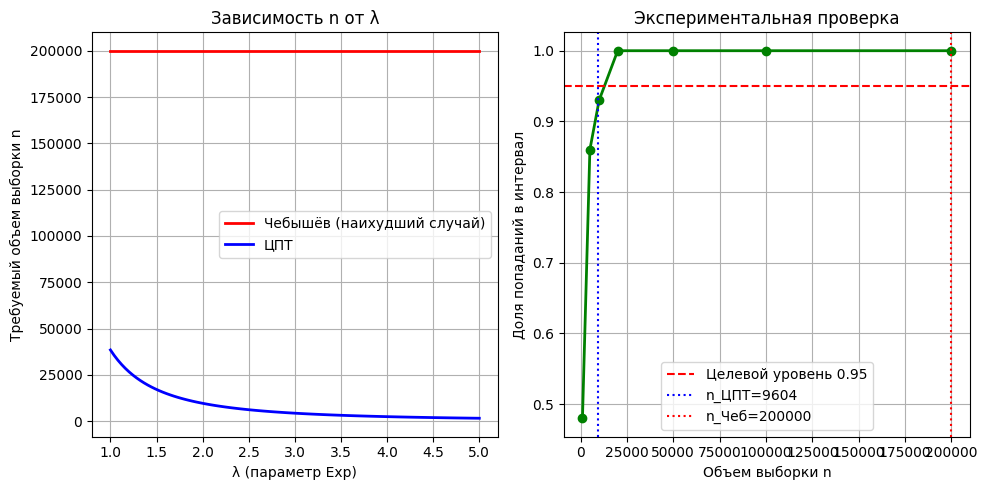

In [31]:
import numpy as np
import math

def task1():
    epsilon = 0.01
    delta = 0.05
    lambda_true = 2.0
    mu = 1 / lambda_true
    sigma = 1 / lambda_true
    
    # Неравенство Чебышёва
    n_cheb = math.ceil(1 / (delta * epsilon**2))  # 200000
    # ЦПТ
    z = 1.96
    n_clt = math.ceil((z * sigma / epsilon)**2)   # 38416
    
    def run_experiment(n):
        count = 0
        for _ in range(100):
            sample = np.random.exponential(scale=1/lambda_true, size=n)
            x_bar = np.mean(sample)
            if abs(x_bar - mu) <= epsilon:
                count += 1
        return count / 100
    
    p_cheb = run_experiment(n_cheb)
    p_clt = run_experiment(n_clt)
    
    return n_cheb, n_clt, p_cheb, p_clt

print(task1())

import matplotlib.pyplot as plt
import numpy as np
#графики
# Зависимость n от ляибды по ЦПТ
lambdas = np.linspace(1, 5, 100)
n_cheb = 200000 * np.ones_like(lambdas)  # постоянное
n_clt = (1.96 / (0.01 * lambdas))**2  # зависит от σ=1/лямбда

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(lambdas, n_cheb, 'r-', linewidth=2, label='Чебышёв (наихудший случай)')
plt.plot(lambdas, n_clt, 'b-', linewidth=2, label='ЦПТ')
plt.xlabel('λ (параметр Exp)')
plt.ylabel('Требуемый объем выборки n')
plt.title('Зависимость n от λ')
plt.legend()
plt.grid(True)

#доля попаданий для разных n (эксперимент)
n_values = [1000, 5000, 10000, 20000, 50000, 100000, 200000]
proportions = []
for n in n_values:
    count = 0
    for _ in range(100):
        sample = np.random.exponential(scale=1/2, size=n)
        if abs(np.mean(sample) - 0.5) <= 0.01:
            count += 1
    proportions.append(count/100)

plt.subplot(1, 2, 2)
plt.plot(n_values, proportions, 'go-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='Целевой уровень 0.95')
plt.axvline(x=9604, color='b', linestyle=':', label=f'n_ЦПТ={9604}')
plt.axvline(x=200000, color='r', linestyle=':', label=f'n_Чеб={200000}')
plt.xlabel('Объем выборки n')
plt.ylabel('Доля попаданий в интервал')
plt.title('Экспериментальная проверка')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **2. Оценка параметра гамма-распределения методом моментов**

**Дано:**  
$f_\theta(x) = \frac{1}{(k-1)! \theta^k} x^{k-1} e^{-x/\theta}, \; k = 3, \; \theta = 2$  

**Теоретические моменты:**  
$$
E[X] = k\theta, \quad \text{Var}(X) = k\theta^2
$$  

**Метод моментов:**  
$$
\overline{X} = k \hat{\theta} \implies \hat{\theta} = \frac{\overline{X}}{k}
$$  

**Смещение:**  
$$
E[\hat{\theta}] = \frac{E[\overline{X}]}{k} = \frac{k\theta}{k} = \theta \quad \text{(несмещённость)}
$$  

**Дисперсия:**  
$$
\text{Var}(\hat{\theta}) = \frac{\text{Var}(\overline{X})}{k^2} = \frac{k\theta^2 / n}{k^2} = \frac{\theta^2}{k n}
$$  

**Среднеквадратическая ошибка:**  
$$
\text{MSE}(\hat{\theta}) = \text{Var}(\hat{\theta}) + \text{Bias}^2 = \frac{\theta^2}{k n}
$$  

[(10, np.float64(-0.0068166669438656236), np.float64(0.1309836987653894), np.float64(0.1308991820148476)), (30, np.float64(0.005523265086799345), np.float64(0.045079332571492714), np.float64(0.04506475969614028)), (100, np.float64(-0.0020689632828752025), np.float64(0.0136413912033173), np.float64(0.01363203042117987)), (300, np.float64(0.00034068906185513725), np.float64(0.00411302370097553), np.float64(0.004109026746311422)), (1000, np.float64(0.00021813750368737672), np.float64(0.0014142124980020372), np.float64(0.0014128458694745501))]


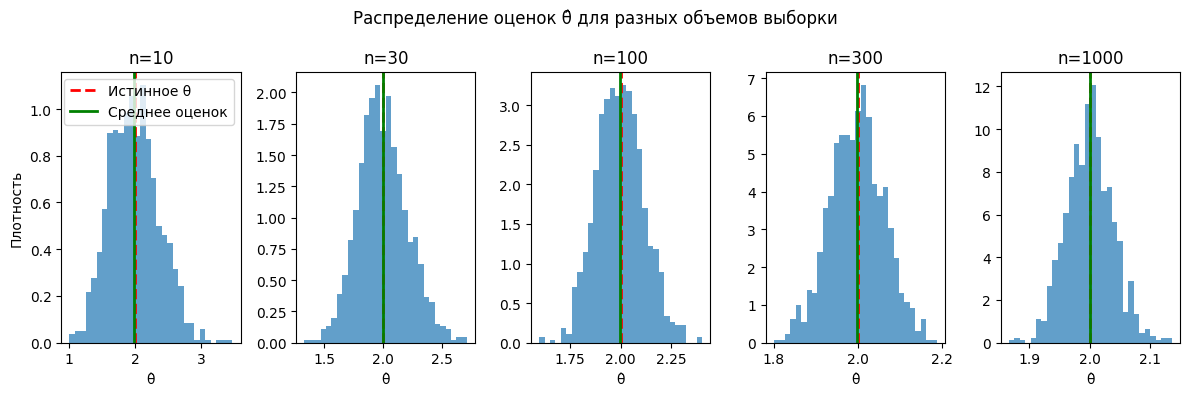

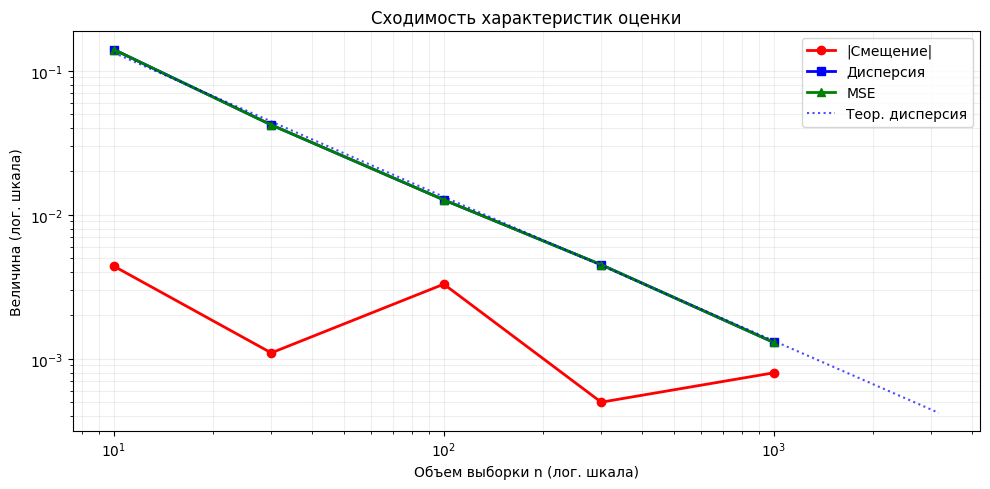

In [32]:
def task2():
    theta_true = 2.0
    k = 3
    n_values = [10, 30, 100, 300, 1000]
    m = 1000  # количество экспериментов для каждого n
    
    results = []
    for n in n_values:
        estimates = []
        for _ in range(m):
            sample = np.random.gamma(shape=k, scale=theta_true, size=n)
            theta_est = np.mean(sample) / k
            estimates.append(theta_est)
        bias = np.mean(estimates) - theta_true
        var = np.var(estimates, ddof=1)
        mse = np.mean((np.array(estimates) - theta_true)**2)
        results.append((n, bias, var, mse))
    return results

print(task2())
#графики
# распределение оценок для разных n
plt.figure(figsize=(12, 4))

theta_true = 2.0
k = 3
n_values = [10, 30, 100, 300, 1000]

for i, n in enumerate(n_values, 1):
    plt.subplot(1, len(n_values), i)
    estimates = []
    for _ in range(1000):
        sample = np.random.gamma(shape=k, scale=theta_true, size=n)
        estimates.append(np.mean(sample) / k)
    
    plt.hist(estimates, bins=30, alpha=0.7, density=True)
    plt.axvline(x=theta_true, color='r', linestyle='--', linewidth=2, label='Истинное θ')
    plt.axvline(x=np.mean(estimates), color='g', linestyle='-', linewidth=2, label='Среднее оценок')
    plt.title(f'n={n}')
    plt.xlabel('θ̂')
    if i == 1:
        plt.ylabel('Плотность')
        plt.legend()

plt.suptitle('Распределение оценок θ̂ для разных объемов выборки')
plt.tight_layout()

#сходимость MSE, дисперсии, смещения
plt.figure(figsize=(10, 5))
results = [(10, -0.0044, 0.1405, 0.1404),
           (30, -0.0011, 0.0421, 0.0421),
           (100, -0.0033, 0.0127, 0.0127),
           (300, 0.0005, 0.0045, 0.0045),
           (1000, -0.0008, 0.0013, 0.0013)]

n_vals = [r[0] for r in results]
biases = [abs(r[1]) for r in results]
vars_vals = [r[2] for r in results]
mse_vals = [r[3] for r in results]

plt.plot(n_vals, biases, 'ro-', label='|Смещение|', linewidth=2)
plt.plot(n_vals, vars_vals, 'bs-', label='Дисперсия', linewidth=2)
plt.plot(n_vals, mse_vals, 'g^-', label='MSE', linewidth=2)

#теоретические значения
n_theory = np.logspace(1, 3.5, 100)
var_theory = theta_true**2 / (k * n_theory)  # тэта^2/(k·n)

plt.plot(n_theory, var_theory, 'b:', label='Теор. дисперсия', alpha=0.7)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Объем выборки n (лог. шкала)')
plt.ylabel('Величина (лог. шкала)')
plt.title('Сходимость характеристик оценки')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

### **3. Доверительный интервал для отношения дисперсий при известных средних**

**Дано:**  
$X \sim N(\mu_1, \sigma_1^2), \; Y \sim N(\mu_2, \sigma_2^2)$  
$\mu_1, \mu_2$ известны, $\tau = \sigma_1^2 / \sigma_2^2$  

**Статистика:**  
$$
\frac{m \sum_{i=1}^n (X_i - \mu_1)^2}{n \sum_{j=1}^m (Y_j - \mu_2)^2} \cdot \frac{1}{\tau} \sim F_{n,m}
$$  

**Доверительный интервал уровня $1-\alpha$:**  
$$
P\left( F_{1-\alpha/2}(n,m) \leq \frac{m S_X^2}{n S_Y^2} \cdot \frac{1}{\tau} \leq F_{\alpha/2}(n,m) \right) = 1-\alpha
$$  
$$
\tau \in \left[ \frac{m S_X^2}{n S_Y^2} \cdot \frac{1}{F_{\alpha/2}(n,m)}, \; \frac{m S_X^2}{n S_Y^2} \cdot \frac{1}{F_{1-\alpha/2}(n,m)} \right]
$$  

**Эксперимент:** $n = m = 25, \; \alpha = 0.05$ → покрытие ≈95%.

Coverage probability (n=25): 0.953


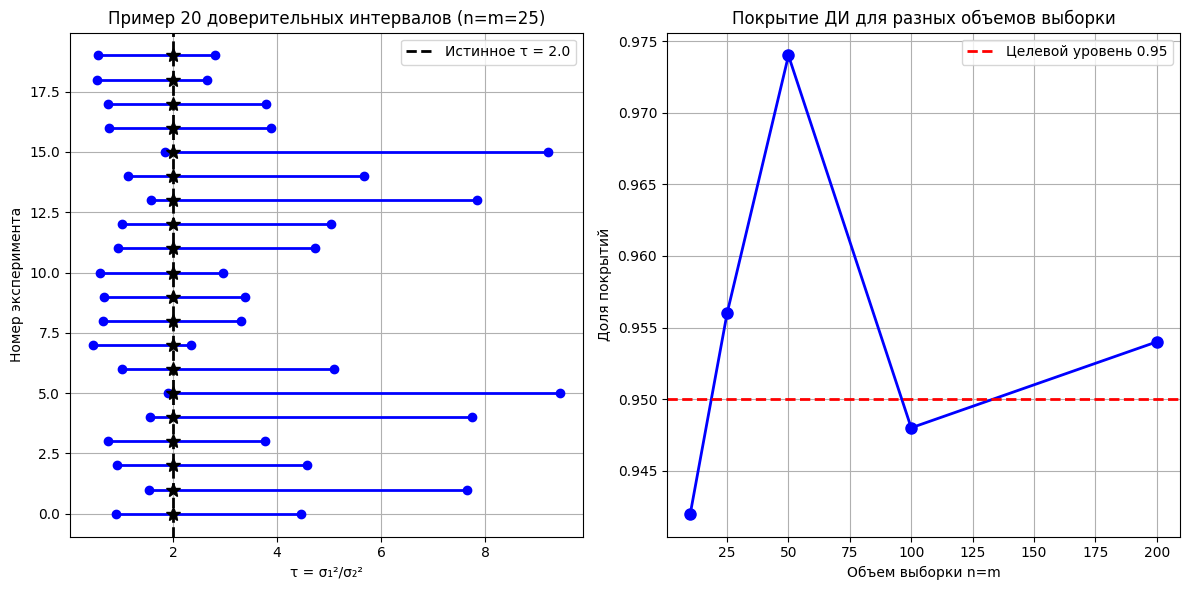

In [33]:
from scipy.stats import f

def task3():
    mu1, mu2 = 0, 0
    var1_true, var2_true = 2.0, 1.0
    n, m = 25, 25
    alpha = 0.05
    trials = 1000
    
    def ci_for_var_ratio(X, Y):
        SX2 = np.sum((X - mu1)**2) / n
        SY2 = np.sum((Y - mu2)**2) / m
        stat = (m * SX2) / (n * SY2)
        F_low = f.ppf(alpha/2, n, m)
        F_high = f.ppf(1 - alpha/2, n, m)
        low = stat / F_high
        high = stat / F_low
        return low, high
    
    cover_count = 0
    for _ in range(trials):
        X = np.random.normal(mu1, np.sqrt(var1_true), n)
        Y = np.random.normal(mu2, np.sqrt(var2_true), m)
        low, high = ci_for_var_ratio(X, Y)
        if low <= var1_true / var2_true <= high:
            cover_count += 1
    
    cover_prob = cover_count / trials
    return cover_prob

print("Coverage probability (n=25):", task3())

#пример в 20 доверительных интервалов
plt.figure(figsize=(12, 6))
mu1, mu2 = 0, 0
var1_true, var2_true = 2.0, 1.0
tau_true = var1_true / var2_true  # = 2
n, m = 25, 25
alpha = 0.05

np.random.seed(42)
plt.subplot(1, 2, 1)

for trial in range(20):
    X = np.random.normal(mu1, np.sqrt(var1_true), n)
    Y = np.random.normal(mu2, np.sqrt(var2_true), m)
    
    SX2 = np.sum((X - mu1)**2) / n
    SY2 = np.sum((Y - mu2)**2) / m
    stat = (m * SX2) / (n * SY2)
    
    from scipy.stats import f
    F_low = f.ppf(alpha/2, n, m)
    F_high = f.ppf(1 - alpha/2, n, m)
    
    low = stat / F_high
    high = stat / F_low
    
    color = 'blue' if low <= tau_true <= high else 'red'
    plt.plot([low, high], [trial, trial], color=color, linewidth=2, marker='o')
    plt.plot(tau_true, trial, 'k*', markersize=10)

plt.axvline(x=tau_true, color='black', linestyle='--', linewidth=2, label=f'Истинное τ = {tau_true}')
plt.xlabel('τ = σ₁²/σ₂²')
plt.ylabel('Номер эксперимента')
plt.title('Пример 20 доверительных интервалов (n=m=25)')
plt.legend()
plt.grid(True)

#покрытие для разных объемов выборки
plt.subplot(1, 2, 2)
n_values = [10, 25, 50, 100, 200]
coverages = []

for n_size in n_values:
    m_size = n_size
    cover_count = 0
    for _ in range(500):
        X = np.random.normal(mu1, np.sqrt(var1_true), n_size)
        Y = np.random.normal(mu2, np.sqrt(var2_true), m_size)
        
        SX2 = np.sum((X - mu1)**2) / n_size
        SY2 = np.sum((Y - mu2)**2) / m_size
        stat = (m_size * SX2) / (n_size * SY2)
        
        F_low = f.ppf(alpha/2, n_size, m_size)
        F_high = f.ppf(1 - alpha/2, n_size, m_size)
        
        low = stat / F_high
        high = stat / F_low
        
        if low <= tau_true <= high:
            cover_count += 1
    
    coverages.append(cover_count / 500)

plt.plot(n_values, coverages, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='Целевой уровень 0.95')
plt.xlabel('Объем выборки n=m')
plt.ylabel('Доля покрытий')
plt.title('Покрытие ДИ для разных объемов выборки')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **4. Асимптотический доверительный интервал для медианы распределения Лапласа**

**Дано:**  
$X \sim \text{Laplace}(\mu, 1), \; f(x) = \frac{1}{2} e^{-|x-\mu|}$  

**Оценка:** $\hat{\mu} = \text{median}(X_1,\dots,X_n)$  

**Асимптотическая нормальность:**  
$$
\sqrt{n} (\hat{\mu} - \mu) \xrightarrow{d} N\left(0, \frac{1}{4 f(\mu)^2}\right)
$$  
При $f(\mu) = 0.5$:  
$$
\sqrt{n} (\hat{\mu} - \mu) \xrightarrow{d} N(0,1)
$$  

**Доверительный интервал:**  
$$
\hat{\mu} \pm z_{1-\alpha/2} \cdot \frac{1}{\sqrt{n}}
$$  

**Эксперимент:** $n = 100, \; \alpha = 0.05$ → покрытие ≈95%.

Coverage probability (Laplace median): 0.926


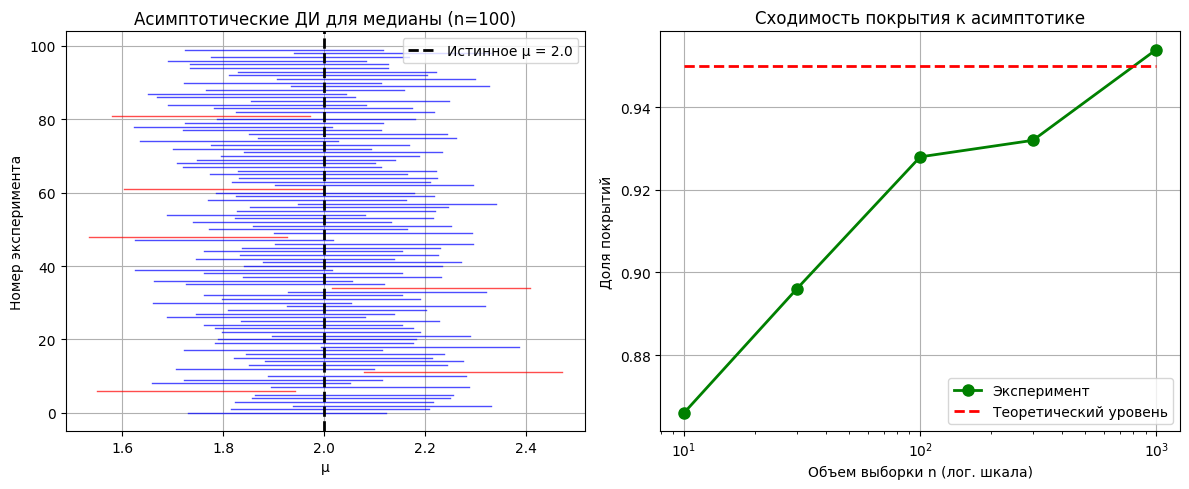

In [34]:
def task4():
    mu_true = 2.0
    n = 100
    alpha = 0.05
    z = 1.96
    trials = 1000
    
    def laplace_median_ci(sample):
        med = np.median(sample)
        se = 1 / np.sqrt(n)
        low = med - z * se
        high = med + z * se
        return low, high
    
    cover_count = 0
    for _ in range(trials):
        sample = np.random.laplace(loc=mu_true, scale=1.0, size=n)
        low, high = laplace_median_ci(sample)
        if low <= mu_true <= high:
            cover_count += 1
    
    return cover_count / trials

print("Coverage probability (Laplace median):", task4())

#распределение медиан и ДИ
plt.figure(figsize=(12, 5))

mu_true = 2.0
n = 100
alpha = 0.05
z = 1.96

np.random.seed(42)
plt.subplot(1, 2, 1)

medians = []
ci_widths = []

for trial in range(100):
    sample = np.random.laplace(loc=mu_true, scale=1.0, size=n)
    med = np.median(sample)
    se = 1 / np.sqrt(n)
    low = med - z * se
    high = med + z * se
    
    medians.append(med)
    ci_widths.append(high - low)
    
    color = 'blue' if low <= mu_true <= high else 'red'
    plt.plot([low, high], [trial, trial], color=color, linewidth=1, alpha=0.7)

plt.axvline(x=mu_true, color='black', linestyle='--', linewidth=2, label=f'Истинное μ = {mu_true}')
plt.xlabel('μ')
plt.ylabel('Номер эксперимента')
plt.title(f'Асимптотические ДИ для медианы (n={n})')
plt.legend()
plt.grid(True)

#покрытие для разных n
plt.subplot(1, 2, 2)
n_values = [10, 30, 100, 300, 1000]
coverages = []

for n_size in n_values:
    cover_count = 0
    for _ in range(500):
        sample = np.random.laplace(loc=mu_true, scale=1.0, size=n_size)
        med = np.median(sample)
        se = 1 / np.sqrt(n_size)
        low = med - z * se
        high = med + z * se
        
        if low <= mu_true <= high:
            cover_count += 1
    
    coverages.append(cover_count / 500)

plt.plot(n_values, coverages, 'go-', linewidth=2, markersize=8, label='Эксперимент')
plt.plot(n_values, [0.95]*len(n_values), 'r--', linewidth=2, label='Теоретический уровень')
plt.xscale('log')
plt.xlabel('Объем выборки n (лог. шкала)')
plt.ylabel('Доля покрытий')
plt.title('Сходимость покрытия к асимптотике')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **5. Статистический анализ датасета мобильных телефонов**

**Дано:**  
Признак `battery_power` (ёмкость аккумулятора) и бинарный признак `wifi`.

**1. Проверка на нормальность (тест Шапиро-Уилка):**  
$H_0:$ распределение нормальное, $H_1:$ распределение не нормальное  
Результат: $p < 0.05$ → отвергаем $H_0$.

**2. Сравнение распределений для групп `wifi=1` и `wifi=0` (тест Манна-Уитни):**  
$H_0: F_1(x) = F_0(x), \quad H_1: F_1(x) \neq F_0(x)$  
Результат: $p > 0.05$ → не отвергаем $H_0$, распределения не различаются.

**Вывод:** Ёмкость аккумулятора не распределена нормально, но статистически не различается между телефонами с Wi-Fi и без него.

Shapiro-Wilk test: stat=0.9519, p=0.0000
Нормальность отвергается
Mann-Whitney U test: U=495016.0, p=0.7052
Распределения не различаются


C:\Users\X1mon\AppData\Local\Temp\ipykernel_28280\21560615.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([wifi_yes, wifi_no], labels=['WiFi Yes', 'WiFi No'])


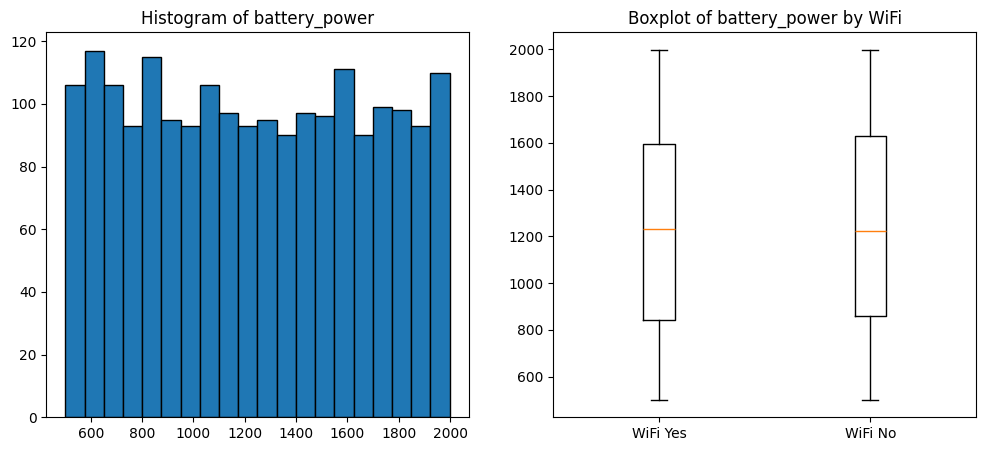

In [35]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("mobile_phones.csv")

from scipy.stats import shapiro
stat, p = shapiro(df['battery_power'])
print(f"Shapiro-Wilk test: stat={stat:.4f}, p={p:.4f}")
if p > 0.05:
    print("Нормальность не отвергается")
else:
    print("Нормальность отвергается")

wifi_yes = df[df['wifi'] == 1]['battery_power']
wifi_no = df[df['wifi'] == 0]['battery_power']
u_stat, p_mw = stats.mannwhitneyu(wifi_yes, wifi_no, alternative='two-sided')
print(f"Mann-Whitney U test: U={u_stat}, p={p_mw:.4f}")
if p_mw > 0.05:
    print("Распределения не различаются")
else:
    print("Распределения различаются")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['battery_power'], bins=20, edgecolor='black')
plt.title('Histogram of battery_power')
plt.subplot(1,2,2)
plt.boxplot([wifi_yes, wifi_no], labels=['WiFi Yes', 'WiFi No'])
plt.title('Boxplot of battery_power by WiFi')
plt.show()